In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
import warnings
from pathlib import Path
from sklearn.metrics import mutual_info_score
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from scipy.spatial.distance import squareform

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
np.random.seed(42)

PROJECT = Path('.')
DATA = PROJECT / 'data'

print("Libraries loaded ✓")

Libraries loaded ✓


In [2]:
fm = pd.read_parquet(DATA / 'features/feature_matrix_v3.parquet')

with open(DATA / 'features/feature_meta_v3.json') as f:
    meta = json.load(f)
feature_names = meta['features']
print(f"Feature matrix: {fm.shape}")
print(f"Features: {len(feature_names)}")

X = fm[feature_names].copy()
y = fm['y'].values

model = joblib.load(DATA / 'models/lgb_v3.joblib')
print(f"\nLGB model loaded, n_features={model.n_features_}")
print(f"Samples: {len(X)} | Label balance: {y.mean():.3f} (UP)")

nan_pct = X.isna().mean()
nan_cols = nan_pct[nan_pct > 0]
if len(nan_cols) > 0:
    print(f"\nFeatures with NaN: {len(nan_cols)}")
    print(nan_cols.sort_values(ascending=False).head(10))
else:
    print("\nNo NaN values ✓")

Feature matrix: (35083, 123)
Features: 78

LGB model loaded, n_features=78
Samples: 35083 | Label balance: 0.500 (UP)

Features with NaN: 9
v_avg_size_6h      0.451216
v_buy_ratio_6h     0.451216
v_vwap_6h          0.451216
v_avg_size_12h     0.384716
v_buy_ratio_12h    0.384716
v_vwap_12h         0.384716
v_avg_size_24h     0.332098
v_buy_ratio_24h    0.332098
v_vwap_24h         0.332098
dtype: float64


In [3]:
X_filled = X.fillna(X.median())

corr_matrix = X_filled.corr()
print(f"Correlation matrix: {corr_matrix.shape}")

N = len(X_filled)
n_bins = int(1 + np.log2(N))
print(f"NMI bins: {n_bins} (Sturges, N={N})")

X_discrete = X_filled.copy()
for col in X_discrete.columns:
    X_discrete[col] = pd.qcut(X_discrete[col], q=n_bins, labels=False, duplicates='drop')

n_feat = len(feature_names)
nmi_matrix = np.zeros((n_feat, n_feat))

from itertools import combinations

print(f"Computing NMI for {n_feat*(n_feat-1)//2} pairs...")
for i, j in combinations(range(n_feat), 2):
    mi = mutual_info_score(X_discrete.iloc[:, i], X_discrete.iloc[:, j])

    h_i = mutual_info_score(X_discrete.iloc[:, i], X_discrete.iloc[:, i])
    h_j = mutual_info_score(X_discrete.iloc[:, j], X_discrete.iloc[:, j])
    nmi = mi / max(h_i, h_j) if max(h_i, h_j) > 0 else 0
    nmi_matrix[i, j] = nmi
    nmi_matrix[j, i] = nmi

np.fill_diagonal(nmi_matrix, 1.0)
nmi_df = pd.DataFrame(nmi_matrix, index=feature_names, columns=feature_names)
print("NMI matrix computed ✓")

Correlation matrix: (78, 78)
NMI bins: 16 (Sturges, N=35083)
Computing NMI for 3003 pairs...


NMI matrix computed ✓


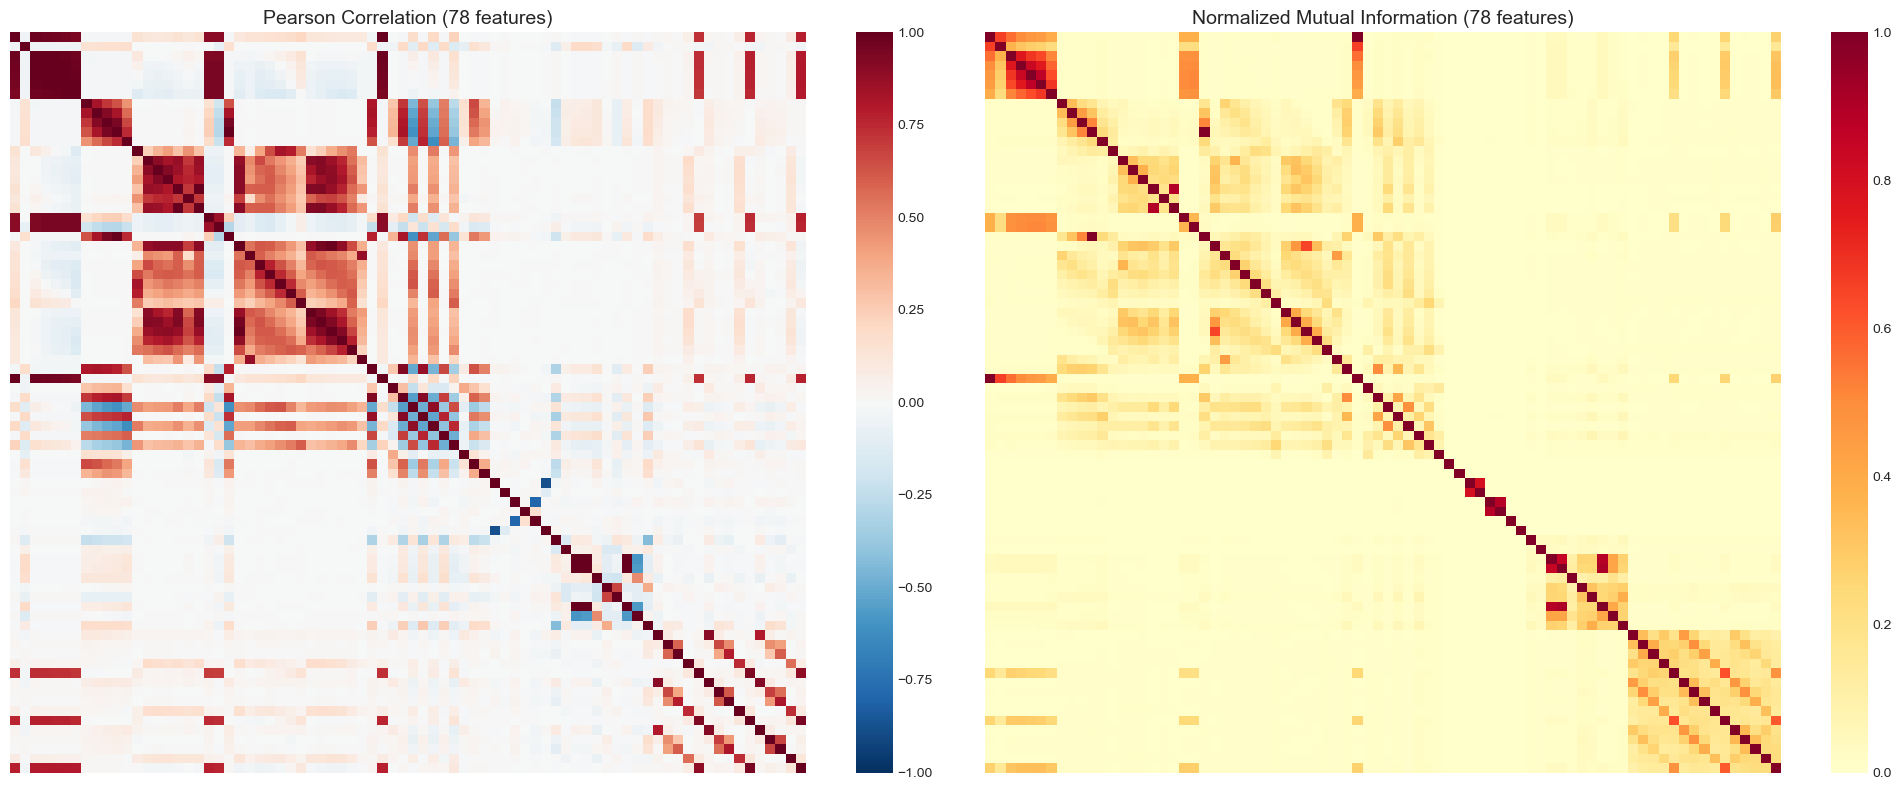

Pairs with |corr|<0.1 but NMI>0.3 (nonlinear dependencies): 10
           feat_i            feat_j     corr      nmi
        t_dow_sin         t_dow_cos 0.010941 0.889075
       t_hour_sin        t_hour_cos 0.002794 0.803559
p_price_extremity       p_frac_diff 0.046271 0.657269
          p_price p_price_extremity 0.046271 0.657269
  ob_liquidityNum  ob_vol_liq_ratio 0.087369 0.389935
p_price_extremity           p_ema_5 0.046501 0.371133
      v_count_24h      v_volume_24h 0.083168 0.355654
      v_count_12h      v_volume_12h 0.085151 0.347086
       v_count_6h       v_volume_6h 0.085342 0.333549
p_price_extremity          p_ema_10 0.046285 0.312657


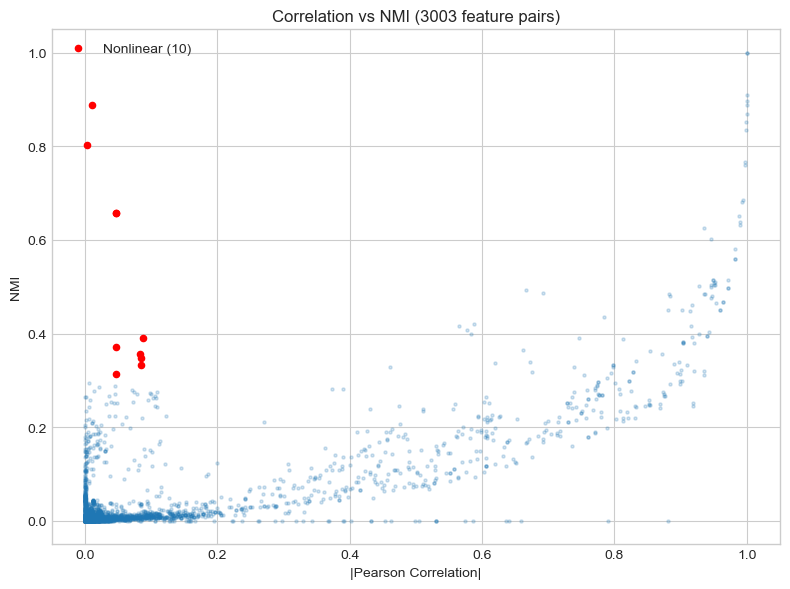

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

sns.heatmap(corr_matrix, ax=axes[0], cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            xticklabels=False, yticklabels=False)
axes[0].set_title('Pearson Correlation (78 features)', fontsize=14)

sns.heatmap(nmi_df, ax=axes[1], cmap='YlOrRd', vmin=0, vmax=1,
            xticklabels=False, yticklabels=False)
axes[1].set_title('Normalized Mutual Information (78 features)', fontsize=14)

plt.tight_layout()
plt.savefig(str(DATA / 'features/cfi_corr_nmi_heatmaps.png'), dpi=150, bbox_inches='tight')
plt.show()

pairs_data = []
for i, j in combinations(range(n_feat), 2):
    pairs_data.append({
        'feat_i': feature_names[i],
        'feat_j': feature_names[j],
        'corr': abs(corr_matrix.iloc[i, j]),
        'nmi': nmi_matrix[i, j]
    })
pairs_df = pd.DataFrame(pairs_data)

nonlinear = pairs_df[(pairs_df['corr'] < 0.1) & (pairs_df['nmi'] > 0.3)].sort_values('nmi', ascending=False)
print(f"Pairs with |corr|<0.1 but NMI>0.3 (nonlinear dependencies): {len(nonlinear)}")
if len(nonlinear) > 0:
    print(nonlinear.head(10).to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(pairs_df['corr'], pairs_df['nmi'], alpha=0.2, s=5)
ax.set_xlabel('|Pearson Correlation|')
ax.set_ylabel('NMI')
ax.set_title('Correlation vs NMI (3003 feature pairs)')
if len(nonlinear) > 0:
    ax.scatter(nonlinear['corr'], nonlinear['nmi'], c='red', s=20, label=f'Nonlinear ({len(nonlinear)})')
    ax.legend()
plt.tight_layout()
plt.show()

In [5]:
def cluster_kmeans_base(corr_matrix, max_num_clusters=None, n_init=10):
    """
    ONC base clustering (López de Prado Snippet 4.1).
    Находит оптимальное k через silhouette quality metric.
    """

    dist = ((1 - corr_matrix) / 2.0) ** 0.5

    n = dist.shape[0]
    if max_num_clusters is None:
        max_num_clusters = n // 2
    max_num_clusters = min(max_num_clusters, n - 1)

    best_q = -np.inf
    best_labels = None
    best_k = 2
    silhouette_scores = {}

    for k in range(2, max_num_clusters + 1):
        km = KMeans(n_clusters=k, n_init=n_init, random_state=42)
        labels = km.fit_predict(dist)

        sil = silhouette_samples(dist, labels, metric='precomputed')
        q = sil.mean() / (sil.std() + 1e-10)
        silhouette_scores[k] = {'q': q, 'mean_sil': sil.mean(), 'std_sil': sil.std()}

        if q > best_q:
            best_q = q
            best_labels = labels
            best_k = k

    return best_labels, best_k, silhouette_scores

def make_new_outputs(corr_matrix, labels):
    """
    ONC re-clustering step (López de Prado Snippet 4.2).
    Перегруппировывает элементы из кластеров с отрицательным средним silhouette.
    """
    dist = ((1 - corr_matrix) / 2.0) ** 0.5
    sil = silhouette_samples(dist, labels, metric='precomputed')

    cluster_means = {}
    for c in np.unique(labels):
        mask = labels == c
        cluster_means[c] = sil[mask].mean()

    bad_clusters = [c for c, s in cluster_means.items() if s < 0]

    if len(bad_clusters) == 0:
        return labels

    bad_mask = np.isin(labels, bad_clusters)
    n_bad = bad_mask.sum()

    if n_bad < 2:
        return labels

    bad_dist = dist[bad_mask][:, bad_mask]
    if n_bad <= 3:

        good_clusters = [c for c in np.unique(labels) if c not in bad_clusters]
        new_labels = labels.copy()
        for idx in np.where(bad_mask)[0]:
            best_c = min(good_clusters, key=lambda c: dist[idx, labels == c].mean())
            new_labels[idx] = best_c
        return new_labels

    re_labels, _, _ = cluster_kmeans_base(
        1 - 2 * bad_dist**2,
        max_num_clusters=min(n_bad // 2, len(np.unique(labels)))
    )

    new_labels = labels.copy()
    offset = labels.max() + 1
    new_labels[bad_mask] = re_labels + offset

    unique = np.unique(new_labels)
    mapping = {old: new for new, old in enumerate(unique)}
    new_labels = np.array([mapping[l] for l in new_labels])

    return new_labels

print("=== ONC on Pearson Correlation ===")
labels_corr, k_corr, scores_corr = cluster_kmeans_base(corr_matrix.values, max_num_clusters=20)
labels_corr = make_new_outputs(corr_matrix.values, labels_corr)
k_corr_final = len(np.unique(labels_corr))
print(f"Optimal k={k_corr_final}, cluster sizes: {dict(zip(*np.unique(labels_corr, return_counts=True)))}")

print("\n=== ONC on NMI ===")
labels_nmi, k_nmi, scores_nmi = cluster_kmeans_base(nmi_df.values, max_num_clusters=20)
labels_nmi = make_new_outputs(nmi_df.values, labels_nmi)
k_nmi_final = len(np.unique(labels_nmi))
print(f"Optimal k={k_nmi_final}, cluster sizes: {dict(zip(*np.unique(labels_nmi, return_counts=True)))}")

cluster_labels = labels_nmi
n_clusters = k_nmi_final

=== ONC on Pearson Correlation ===
Optimal k=14, cluster sizes: {np.int64(0): np.int64(2), np.int64(1): np.int64(11), np.int64(2): np.int64(9), np.int64(3): np.int64(11), np.int64(4): np.int64(3), np.int64(5): np.int64(3), np.int64(6): np.int64(3), np.int64(7): np.int64(3), np.int64(8): np.int64(7), np.int64(9): np.int64(3), np.int64(10): np.int64(6), np.int64(11): np.int64(2), np.int64(12): np.int64(8), np.int64(13): np.int64(7)}

=== ONC on NMI ===


Optimal k=9, cluster sizes: {np.int64(0): np.int64(2), np.int64(1): np.int64(14), np.int64(2): np.int64(11), np.int64(3): np.int64(8), np.int64(4): np.int64(10), np.int64(5): np.int64(16), np.int64(6): np.int64(6), np.int64(7): np.int64(2), np.int64(8): np.int64(9)}


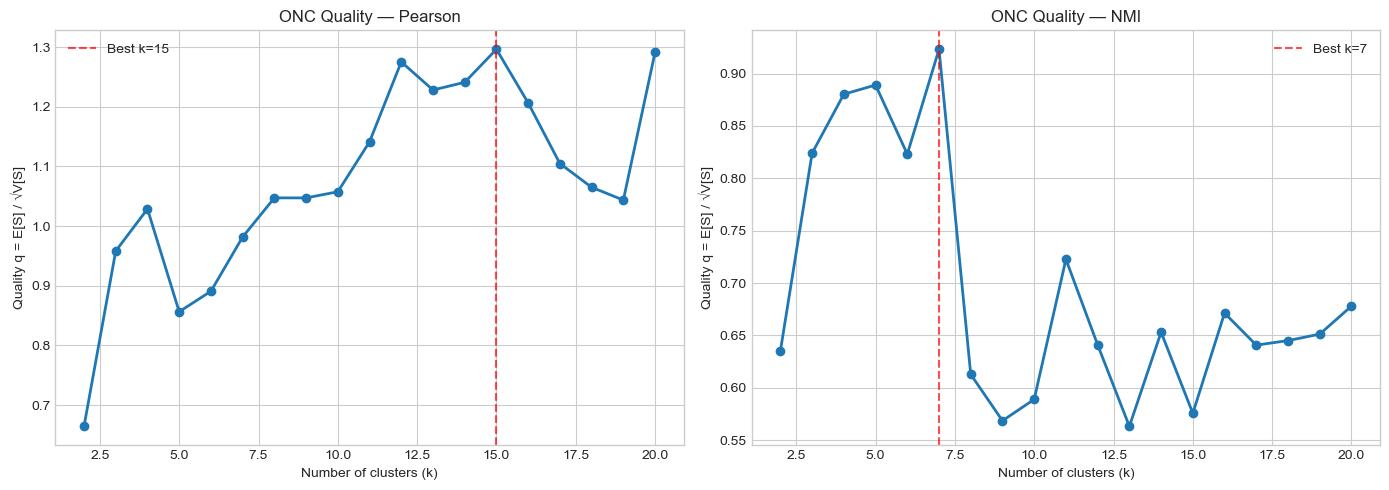


=== Feature Clusters (NMI-based) ===

Cluster 0 (2 features):
  - t_dow_sin
  - t_dow_cos

Cluster 1 (14 features):
  - v_count_6h
  - v_volume_6h
  - v_avg_size_6h
  - v_buy_ratio_6h
  - v_vwap_6h
  - v_count_12h
  - v_volume_12h
  - v_avg_size_12h
  - v_buy_ratio_12h
  - v_vwap_12h
  - v_count_24h
  - v_volume_24h
  - v_avg_size_24h
  - v_buy_ratio_24h

Cluster 2 (11 features):
  - p_price
  - p_price_extremity
  - p_ema_5
  - p_ema_10
  - p_ema_15
  - p_ema_20
  - p_ema_50
  - p_bb_upper
  - p_bb_lower
  - p_frac_diff
  - v_vwap_24h

Cluster 3 (8 features):
  - ob_bestBid
  - ob_bestAsk
  - ob_spread
  - ob_volumeNum
  - ob_liquidityNum
  - ob_midpoint
  - ob_spread_pct
  - ob_vol_liq_ratio

Cluster 4 (10 features):
  - p_std_5
  - p_std_10
  - p_std_15
  - p_std_20
  - p_std_50
  - p_bb_width
  - p_ewm_vol
  - r_realized_vol_24h
  - r_realized_vol_48h
  - r_realized_vol_168h

Cluster 5 (16 features):
  - p_rsi_6
  - p_rsi_10
  - p_rsi_14
  - p_stoch_k
  - p_stoch_d
  - p_williams_

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, scores, title in [(axes[0], scores_corr, 'Pearson'), (axes[1], scores_nmi, 'NMI')]:
    ks = sorted(scores.keys())
    qs = [scores[k]['q'] for k in ks]
    ax.plot(ks, qs, 'o-', linewidth=2)
    best_k = ks[np.argmax(qs)]
    ax.axvline(best_k, color='red', linestyle='--', alpha=0.7, label=f'Best k={best_k}')
    ax.set_xlabel('Number of clusters (k)')
    ax.set_ylabel('Quality q = E[S] / √V[S]')
    ax.set_title(f'ONC Quality — {title}')
    ax.legend()

plt.tight_layout()
plt.show()

print("\n=== Feature Clusters (NMI-based) ===")
clusters = {}
for i, feat in enumerate(feature_names):
    c = cluster_labels[i]
    clusters.setdefault(c, []).append(feat)

for c in sorted(clusters.keys()):
    feats = clusters[c]
    print(f"\nCluster {c} ({len(feats)} features):")
    for f in feats:
        print(f"  - {f}")

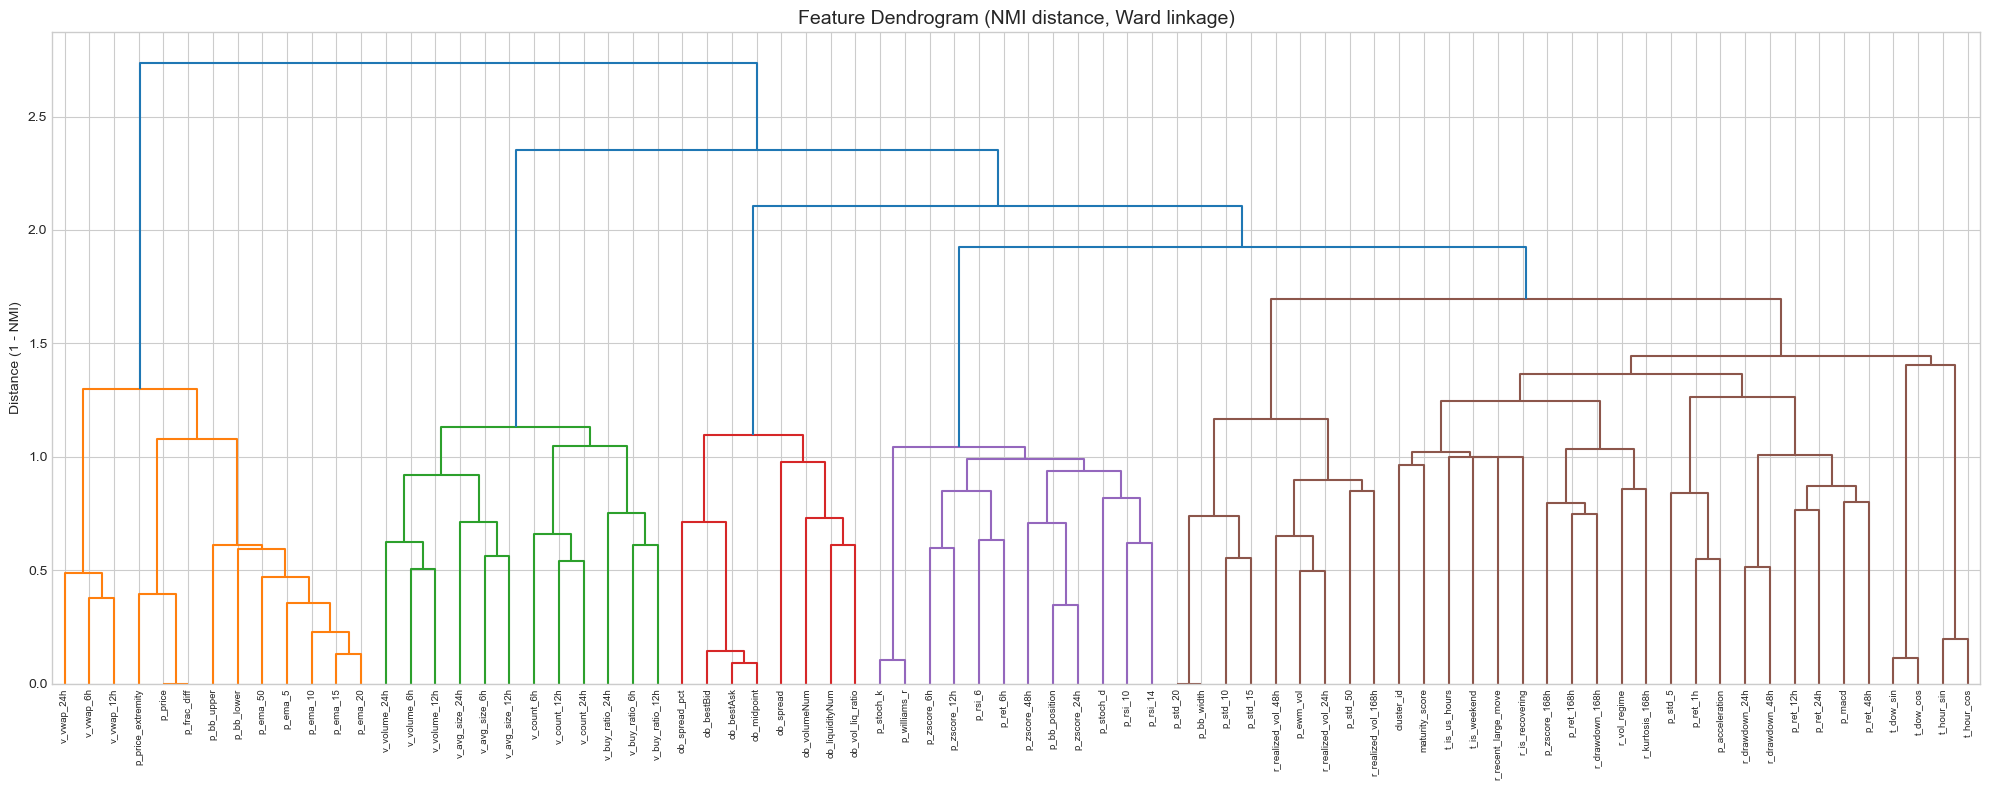

In [7]:
nmi_dist = 1 - nmi_df.values
np.fill_diagonal(nmi_dist, 0)

nmi_dist = (nmi_dist + nmi_dist.T) / 2
nmi_dist = np.clip(nmi_dist, 0, None)

condensed = squareform(nmi_dist, checks=False)
Z = linkage(condensed, method='ward')

fig, ax = plt.subplots(figsize=(20, 8))
dendrogram(Z, labels=feature_names, leaf_rotation=90, leaf_font_size=7, ax=ax,
           color_threshold=0.7 * max(Z[:, 2]))
ax.set_title('Feature Dendrogram (NMI distance, Ward linkage)', fontsize=14)
ax.set_ylabel('Distance (1 - NMI)')
plt.tight_layout()
plt.savefig(str(DATA / 'features/cfi_dendrogram.png'), dpi=150, bbox_inches='tight')
plt.show()

In [8]:
from sklearn.model_selection import KFold
from sklearn.metrics import roc_auc_score
import lightgbm as lgb

mdi_raw = model.feature_importances_
mdi_norm = mdi_raw / mdi_raw.sum()

mdi_per_feat = pd.Series(mdi_norm, index=feature_names, name='MDI')
print("=== Standard MDI (top 15) ===")
print(mdi_per_feat.sort_values(ascending=False).head(15))

cluster_mdi = {}
for c in sorted(clusters.keys()):
    feats = clusters[c]
    cluster_mdi[c] = {
        'features': feats,
        'n_features': len(feats),
        'mdi_sum': sum(mdi_per_feat[f] for f in feats),
        'mdi_mean': np.mean([mdi_per_feat[f] for f in feats]),
        'top_feature': max(feats, key=lambda f: mdi_per_feat[f]),
    }

print("\n=== Clustered MDI ===")
for c in sorted(cluster_mdi.keys(), key=lambda x: cluster_mdi[x]['mdi_sum'], reverse=True):
    info = cluster_mdi[c]
    print(f"Cluster {c}: MDI_sum={info['mdi_sum']:.4f} ({info['n_features']} feats, top: {info['top_feature']})")

=== Standard MDI (top 15) ===
p_ret_168h           0.035619
ob_vol_liq_ratio     0.026263
ob_bestBid           0.024031
ob_volumeNum         0.023176
p_ret_12h            0.019994
p_ret_1h             0.019709
ob_liquidityNum      0.019662
p_ret_48h            0.019139
p_zscore_168h        0.019092
p_price_extremity    0.019092
ob_bestAsk           0.019044
r_kurtosis_168h      0.018427
p_acceleration       0.018095
ob_spread_pct        0.018000
p_price              0.017952
Name: MDI, dtype: float64

=== Clustered MDI ===
Cluster 5: MDI_sum=0.2170 (16 feats, top: p_ret_12h)
Cluster 8: MDI_sum=0.1716 (9 feats, top: p_ret_168h)
Cluster 3: MDI_sum=0.1559 (8 feats, top: ob_vol_liq_ratio)
Cluster 1: MDI_sum=0.1538 (14 feats, top: v_avg_size_24h)
Cluster 4: MDI_sum=0.1374 (10 feats, top: r_realized_vol_24h)
Cluster 2: MDI_sum=0.1291 (11 feats, top: p_price_extremity)
Cluster 7: MDI_sum=0.0147 (2 feats, top: t_hour_sin)
Cluster 0: MDI_sum=0.0126 (2 feats, top: t_dow_sin)
Cluster 6: MDI_sum=0

In [9]:
X_np = X_filled.values
split_idx = int(len(X_np) * 0.7)
X_train, X_test = X_np[:split_idx], X_np[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

lgb_params = model.get_params()
lgb_params['verbose'] = -1
lgb_mda = lgb.LGBMClassifier(**lgb_params)
lgb_mda.fit(X_train, y_train)

baseline_auc = roc_auc_score(y_test, lgb_mda.predict_proba(X_test)[:, 1])
print(f"Baseline OOS AUC: {baseline_auc:.4f}")

n_repeats = 5
feat_mda = {}
for i, feat in enumerate(feature_names):
    drops = []
    for _ in range(n_repeats):
        X_perm = X_test.copy()
        X_perm[:, i] = np.random.permutation(X_perm[:, i])
        perm_auc = roc_auc_score(y_test, lgb_mda.predict_proba(X_perm)[:, 1])
        drops.append(baseline_auc - perm_auc)
    feat_mda[feat] = {'mean': np.mean(drops), 'std': np.std(drops)}

mda_per_feat = pd.Series({f: v['mean'] for f, v in feat_mda.items()}, name='MDA')
print(f"\n=== Standard MDA (top 15) ===")
print(mda_per_feat.sort_values(ascending=False).head(15))

cluster_mda = {}
for c in sorted(clusters.keys()):
    feats = clusters[c]
    feat_indices = [feature_names.index(f) for f in feats]
    drops = []
    for _ in range(n_repeats):
        X_perm = X_test.copy()
        for idx in feat_indices:
            X_perm[:, idx] = np.random.permutation(X_perm[:, idx])
        perm_auc = roc_auc_score(y_test, lgb_mda.predict_proba(X_perm)[:, 1])
        drops.append(baseline_auc - perm_auc)
    cluster_mda[c] = {'mean': np.mean(drops), 'std': np.std(drops), 'n_features': len(feats)}

print(f"\n=== Clustered MDA ===")
for c in sorted(cluster_mda.keys(), key=lambda x: cluster_mda[x]['mean'], reverse=True):
    info = cluster_mda[c]
    feats = clusters[c]
    print(f"Cluster {c}: MDA={info['mean']:.4f}±{info['std']:.4f} ({info['n_features']} feats: {feats[0]}...)")

Baseline OOS AUC: 0.6872



=== Standard MDA (top 15) ===
p_ret_1h             0.006863
p_stoch_k            0.004061
p_price              0.003085
p_williams_r         0.002559
p_zscore_6h          0.002409
p_frac_diff          0.001935
ob_bestBid           0.001851
p_zscore_48h         0.001810
ob_bestAsk           0.001688
ob_midpoint          0.001584
v_buy_ratio_6h       0.001558
r_drawdown_48h       0.001366
p_ret_168h           0.001257
p_price_extremity    0.001202
v_vwap_24h           0.001094
Name: MDA, dtype: float64



=== Clustered MDA ===
Cluster 5: MDA=0.1098±0.0039 (16 feats: p_rsi_6...)
Cluster 2: MDA=0.0135±0.0005 (11 feats: p_price...)
Cluster 3: MDA=0.0084±0.0003 (8 feats: ob_bestBid...)
Cluster 8: MDA=0.0072±0.0007 (9 feats: p_macd...)
Cluster 1: MDA=0.0062±0.0007 (14 feats: v_count_6h...)
Cluster 4: MDA=0.0004±0.0007 (10 feats: p_std_5...)
Cluster 6: MDA=-0.0001±0.0002 (6 feats: r_recent_large_move...)
Cluster 7: MDA=-0.0002±0.0001 (2 feats: t_hour_sin...)
Cluster 0: MDA=-0.0005±0.0002 (2 feats: t_dow_sin...)


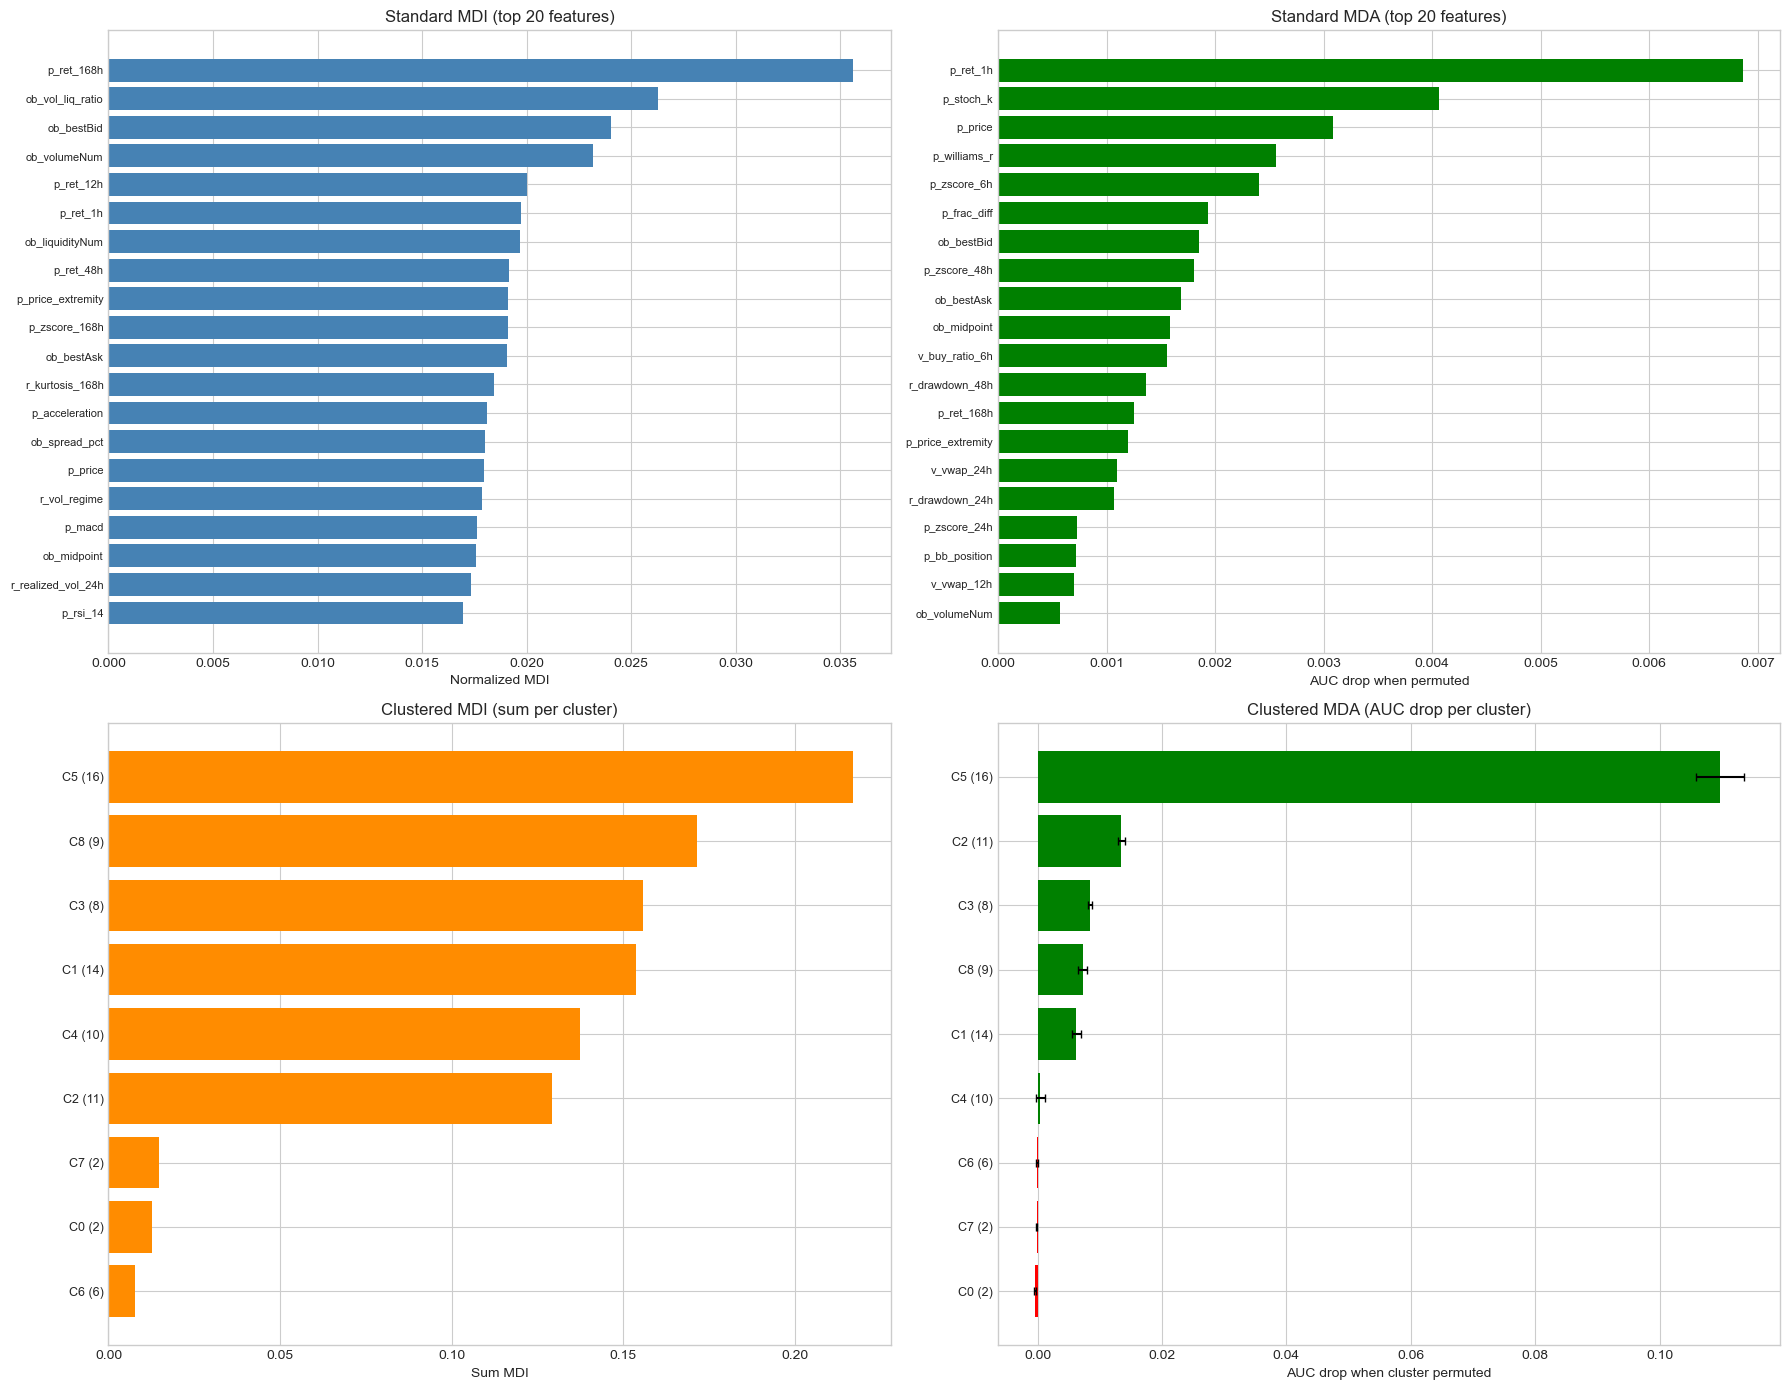

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

top_mdi = mdi_per_feat.sort_values(ascending=True).tail(20)
axes[0, 0].barh(range(len(top_mdi)), top_mdi.values, color='steelblue')
axes[0, 0].set_yticks(range(len(top_mdi)))
axes[0, 0].set_yticklabels(top_mdi.index, fontsize=8)
axes[0, 0].set_title('Standard MDI (top 20 features)')
axes[0, 0].set_xlabel('Normalized MDI')

top_mda = mda_per_feat.sort_values(ascending=True).tail(20)
colors = ['green' if v > 0 else 'red' for v in top_mda.values]
axes[0, 1].barh(range(len(top_mda)), top_mda.values, color=colors)
axes[0, 1].set_yticks(range(len(top_mda)))
axes[0, 1].set_yticklabels(top_mda.index, fontsize=8)
axes[0, 1].set_title('Standard MDA (top 20 features)')
axes[0, 1].set_xlabel('AUC drop when permuted')

c_names = [f"C{c} ({cluster_mdi[c]['n_features']})" for c in sorted(cluster_mdi.keys())]
c_mdi_vals = [cluster_mdi[c]['mdi_sum'] for c in sorted(cluster_mdi.keys())]
sorted_idx = np.argsort(c_mdi_vals)
axes[1, 0].barh(range(len(c_names)), [c_mdi_vals[i] for i in sorted_idx], color='darkorange')
axes[1, 0].set_yticks(range(len(c_names)))
axes[1, 0].set_yticklabels([c_names[i] for i in sorted_idx], fontsize=9)
axes[1, 0].set_title('Clustered MDI (sum per cluster)')
axes[1, 0].set_xlabel('Sum MDI')

c_mda_vals = [cluster_mda[c]['mean'] for c in sorted(cluster_mda.keys())]
c_mda_stds = [cluster_mda[c]['std'] for c in sorted(cluster_mda.keys())]
sorted_idx = np.argsort(c_mda_vals)
colors = ['green' if c_mda_vals[i] > 0 else 'red' for i in sorted_idx]
axes[1, 1].barh(range(len(c_names)), [c_mda_vals[i] for i in sorted_idx],
                xerr=[c_mda_stds[i] for i in sorted_idx], color=colors, capsize=3)
axes[1, 1].set_yticks(range(len(c_names)))
axes[1, 1].set_yticklabels([c_names[i] for i in sorted_idx], fontsize=9)
axes[1, 1].set_title('Clustered MDA (AUC drop per cluster)')
axes[1, 1].set_xlabel('AUC drop when cluster permuted')

plt.tight_layout()
plt.savefig(str(DATA / 'features/cfi_importance_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

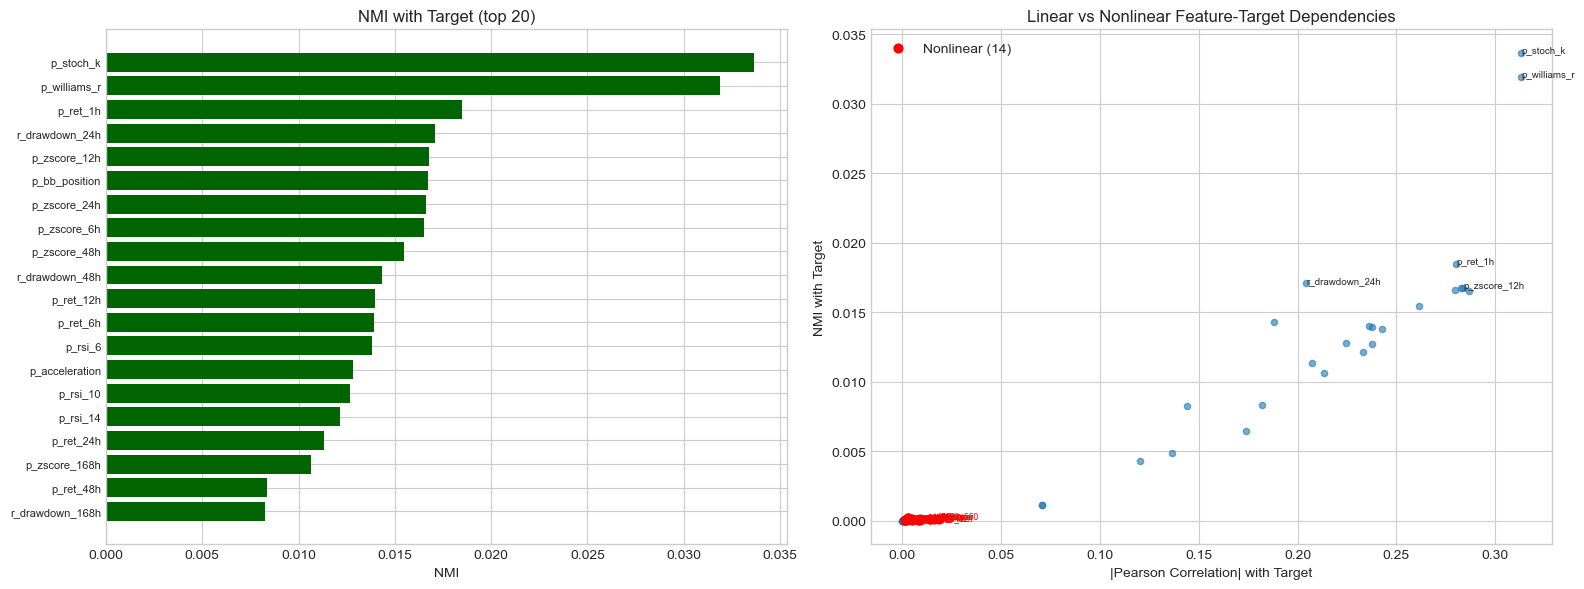

=== Features with strongest NONLINEAR signal (high NMI/corr ratio) ===
                        corr       nmi  nmi_corr_ratio
ob_volumeNum        0.000019  0.000010        0.533798
r_realized_vol_24h  0.000072  0.000010        0.143437
p_price_extremity   0.000540  0.000062        0.114903
p_stoch_k           0.313047  0.033675        0.107572
p_williams_r        0.313047  0.031916        0.101953
ob_vol_liq_ratio    0.000115  0.000011        0.096147
r_drawdown_24h      0.204255  0.017077        0.083605
r_drawdown_48h      0.187935  0.014319        0.076191
v_count_24h         0.003092  0.000210        0.067742
p_ret_1h            0.280339  0.018493        0.065966


In [11]:
nmi_target = {}
corr_target = {}

h_y = mutual_info_score(y, y)

for i, feat in enumerate(feature_names):

    corr_target[feat] = abs(np.corrcoef(X_filled.iloc[:, i], y)[0, 1])

    mi = mutual_info_score(X_discrete.iloc[:, i], y)
    h_x = mutual_info_score(X_discrete.iloc[:, i], X_discrete.iloc[:, i])
    nmi_target[feat] = mi / max(h_x, h_y) if max(h_x, h_y) > 0 else 0

nmi_target_s = pd.Series(nmi_target, name='NMI_target')
corr_target_s = pd.Series(corr_target, name='corr_target')

comparison = pd.DataFrame({'corr': corr_target_s, 'nmi': nmi_target_s, 'mdi': mdi_per_feat, 'mda': mda_per_feat})

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top_nmi_t = nmi_target_s.sort_values(ascending=True).tail(20)
axes[0].barh(range(len(top_nmi_t)), top_nmi_t.values, color='darkgreen')
axes[0].set_yticks(range(len(top_nmi_t)))
axes[0].set_yticklabels(top_nmi_t.index, fontsize=8)
axes[0].set_title('NMI with Target (top 20)')
axes[0].set_xlabel('NMI')

axes[1].scatter(comparison['corr'], comparison['nmi'], alpha=0.6, s=20)
for feat in comparison.nlargest(5, 'nmi').index:
    axes[1].annotate(feat, (comparison.loc[feat, 'corr'], comparison.loc[feat, 'nmi']), fontsize=7)

nonlinear_target = comparison[(comparison['corr'] < 0.02) & (comparison['nmi'] > comparison['nmi'].median())]
if len(nonlinear_target) > 0:
    axes[1].scatter(nonlinear_target['corr'], nonlinear_target['nmi'], c='red', s=40,
                    label=f'Nonlinear ({len(nonlinear_target)})', zorder=5)
    for feat in nonlinear_target.index:
        axes[1].annotate(feat, (comparison.loc[feat, 'corr'], comparison.loc[feat, 'nmi']),
                        fontsize=6, color='red')
    axes[1].legend()
axes[1].set_xlabel('|Pearson Correlation| with Target')
axes[1].set_ylabel('NMI with Target')
axes[1].set_title('Linear vs Nonlinear Feature-Target Dependencies')

plt.tight_layout()
plt.show()

comparison['nmi_corr_ratio'] = comparison['nmi'] / (comparison['corr'] + 1e-6)
print("=== Features with strongest NONLINEAR signal (high NMI/corr ratio) ===")
print(comparison.sort_values('nmi_corr_ratio', ascending=False).head(10)[['corr', 'nmi', 'nmi_corr_ratio']].to_string())

In [12]:
noise_clusters = [c for c, v in cluster_mda.items() if v['mean'] <= 0]
signal_clusters = [c for c, v in cluster_mda.items() if v['mean'] > 0]

noise_features = [f for c in noise_clusters for f in clusters[c]]
signal_features = [f for c in signal_clusters for f in clusters[c]]

print(f"=== Noise Analysis ===")
print(f"Signal clusters: {len(signal_clusters)} ({len(signal_features)} features)")
print(f"Noise clusters: {len(noise_clusters)} ({len(noise_features)} features)")

if noise_features:
    print(f"\nNoise features (MDA≤0, candidates for removal):")
    for c in noise_clusters:
        print(f"  Cluster {c} (MDA={cluster_mda[c]['mean']:.4f}): {clusters[c]}")

print(f"\n=== Feature Reduction Test ===")
signal_indices = [feature_names.index(f) for f in signal_features]

X_train_signal = X_train[:, signal_indices]
X_test_signal = X_test[:, signal_indices]

lgb_reduced = lgb.LGBMClassifier(**lgb_params)
lgb_reduced.fit(X_train_signal, y_train)

auc_full = roc_auc_score(y_test, lgb_mda.predict_proba(X_test)[:, 1])
auc_reduced = roc_auc_score(y_test, lgb_reduced.predict_proba(X_test_signal)[:, 1])

print(f"Full model ({len(feature_names)} features): AUC = {auc_full:.4f}")
print(f"Reduced model ({len(signal_features)} features): AUC = {auc_reduced:.4f}")
print(f"Difference: {auc_reduced - auc_full:+.4f}")

if auc_reduced >= auc_full - 0.005:
    print(f"\n→ Reduced model is competitive! Can drop {len(noise_features)} features safely.")
else:
    print(f"\n→ Noise features contribute marginally. Keep for now.")

=== Noise Analysis ===
Signal clusters: 6 (68 features)
Noise clusters: 3 (10 features)

Noise features (MDA≤0, candidates for removal):
  Cluster 0 (MDA=-0.0005): ['t_dow_sin', 't_dow_cos']
  Cluster 6 (MDA=-0.0001): ['r_recent_large_move', 'r_is_recovering', 't_is_weekend', 't_is_us_hours', 'cluster_id', 'maturity_score']
  Cluster 7 (MDA=-0.0002): ['t_hour_sin', 't_hour_cos']

=== Feature Reduction Test ===


Full model (78 features): AUC = 0.6872
Reduced model (68 features): AUC = 0.6862
Difference: -0.0010

→ Reduced model is competitive! Can drop 10 features safely.


In [13]:
summary_data = []
for c in sorted(clusters.keys()):
    feats = clusters[c]
    summary_data.append({
        'cluster': c,
        'n_features': len(feats),
        'features': ', '.join(feats[:3]) + ('...' if len(feats) > 3 else ''),
        'mdi_sum': cluster_mdi[c]['mdi_sum'],
        'mda_mean': cluster_mda[c]['mean'],
        'mda_std': cluster_mda[c]['std'],
        'is_noise': c in noise_clusters,
        'avg_nmi_target': np.mean([nmi_target[f] for f in feats]),
    })

summary_df = pd.DataFrame(summary_data).sort_values('mda_mean', ascending=False)
print("=== CFI Summary ===")
print(summary_df.to_string(index=False))

cfi_results = {
    'n_features': len(feature_names),
    'n_clusters': n_clusters,
    'baseline_auc': float(baseline_auc),
    'reduced_auc': float(auc_reduced),
    'n_signal_features': len(signal_features),
    'n_noise_features': len(noise_features),
    'signal_features': signal_features,
    'noise_features': noise_features,
    'clusters': {int(c): clusters[c] for c in clusters},
    'cluster_mda': {int(c): {'mean': float(v['mean']), 'std': float(v['std'])} for c, v in cluster_mda.items()},
    'cluster_mdi': {int(c): {'sum': float(cluster_mdi[c]['mdi_sum'])} for c in cluster_mdi},
}

with open(DATA / 'features/cfi_results.json', 'w') as f:
    json.dump(cfi_results, f, indent=2)

print(f"\nResults saved to data/features/cfi_results.json")
print(f"\n=== Key Takeaways ===")
print(f"1. {len(feature_names)} features → {n_clusters} clusters")
print(f"2. Signal clusters: {len(signal_clusters)} ({len(signal_features)} features)")
print(f"3. Noise clusters: {len(noise_clusters)} ({len(noise_features)} features)")
print(f"4. Reduced model AUC: {auc_reduced:.4f} vs full: {auc_full:.4f} ({auc_reduced-auc_full:+.4f})")
print(f"5. CFI корректно обрабатывает substitution effect в коррелированных фичах")

=== CFI Summary ===
 cluster  n_features                                              features  mdi_sum  mda_mean  mda_std  is_noise  avg_nmi_target
       5          16                        p_rsi_6, p_rsi_10, p_rsi_14... 0.217040  0.109750 0.003910     False    1.681821e-02
       2          11                p_price, p_price_extremity, p_ema_5... 0.129132  0.013476 0.000505     False    2.980223e-04
       3           8                  ob_bestBid, ob_bestAsk, ob_spread... 0.155870  0.008402 0.000261     False    1.044378e-05
       8           9                       p_macd, p_ret_24h, p_ret_48h... 0.171638  0.007219 0.000676     False    6.891279e-03
       1          14             v_count_6h, v_volume_6h, v_avg_size_6h... 0.153780  0.006231 0.000709     False    9.278020e-05
       4          10                        p_std_5, p_std_10, p_std_15... 0.137396  0.000439 0.000740     False    1.514683e-05
       6           6 r_recent_large_move, r_is_recovering, t_is_weekend... 0.